# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

## AlpesPlanck

**Integrantes:**
- Daniel Esteban Pardo Pardo
- Samuel Andrés Molina Luna

**Curso:** ISIS2611 - Aprendizaje de Máquina
**Fecha:** 14 de septiembre

# 1. Contexto

En el Laboratorio 1 se construyó para AlpesPlanck un primer modelo de regresión lineal para
estimar la temperatura máxima del día siguiente en la estación de Jena, Alemania, identificando
las variables más influyentes y reflexionando sobre posibles fuentes de sesgo.

En este laboratorio se busca fortalecer ese primer acercamiento evaluando otros enfoques de
modelado (regresión polinomial y regularizada), analizando el efecto de la complejidad sobre la
capacidad de generalización, y cuantificando la incertidumbre del modelo mediante intervalos de
confianza obtenidos por remuestreo (bootstrapping).

Se reutiliza el mismo conjunto de datos del Laboratorio 1, aplicando el mismo proceso de
limpieza y preparación ya validado (Modelo 2 / `df_m2`), de forma que el énfasis de este
laboratorio esté en el modelado, la validación y el análisis del desempeño predictivo.

# 2. Carga de datos y librerías

### Librerías a usar en el transcurso del laboratorio
Librerías de Python para el procesamiento, modelado y análisis de datos:

- Pandas
- Scikit-Learn
- Matplotlib, Seaborn
- NumPy

In [2]:
# Importación de las librerías a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.utils import resample

from sklearn import set_config
set_config(display="diagram")

np.random.seed(42)

### Cargar datos a DataFrames

In [3]:
# Dataset de entrenamiento (mismo del Laboratorio 1)
data = pd.read_csv('data/Datos Lab 1.csv')
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [4]:
# Dataset de prueba / producción (sin etiqueta), igual que en el Laboratorio 1
data_test = pd.read_csv('data/Datos Test Lab 1.csv')
data_test.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


# 3. Reconstrucción del conjunto de datos limpio (Modelo 2 del Laboratorio 1)

Tal como indica el enunciado, este laboratorio no repite la exploración ni el procesamiento de
datos ya realizado en el Laboratorio 1 — se reutiliza directamente la versión resultante de esa
limpieza y preparación (el `df_m2` del Laboratorio 1, correspondiente al modelo optimizado).

A continuación se reproducen, de forma resumida y sin volver a justificar cada decisión, los
mismos pasos de limpieza aplicados en el Laboratorio 1, para partir exactamente del mismo punto.

**3.1 Unicidad — eliminación de duplicados**

In [5]:
df_base = data.copy()
len_inicial = len(df_base)

# Eliminar duplicados exactos
df_base = df_base.drop_duplicates()
duplicados_exactos = len_inicial - len(df_base)

# Manejar fechas duplicadas: conservar la que tenga menos valores NaN
df_base['num_nans'] = df_base.isnull().sum(axis=1)
df_base = df_base.sort_values(by=['fecha', 'num_nans'])
df_base = df_base.drop_duplicates(subset=['fecha'], keep='first')
df_base = df_base.drop(columns=['num_nans'])

print(f"Registros tras depuración de duplicados: {len(df_base)}")

Registros tras depuración de duplicados: 2487


**3.2 Completitud — eliminación de registros sin variable objetivo**

In [6]:
df_base = df_base.dropna(subset=['temp_max_manana'])
print(f"Registros con temp_max_manana no nula: {len(df_base)}")

Registros con temp_max_manana no nula: 2394


**3.3 Validez — tratamiento de valores anómalos y centinela**

In [7]:
# Presión atmosférica (Dominio real ~940 a 1040 mbar)
cols_presion = [c for c in df_base.columns if 'presion' in c and 'desv' not in c and 'std' not in c]
for col in cols_presion:
    df_base.loc[(df_base[col] < 940) | (df_base[col] > 1040), col] = np.nan

# Humedad relativa (Clipping al 100% y depuración de 0s artificiales)
cols_humedad = [c for c in df_base.columns if 'humedad' in c]
for col in cols_humedad:
    df_base.loc[df_base[col] > 100, col] = 100.0
    df_base.loc[df_base[col] <= 0.05, col] = np.nan

# Viento, ráfagas y desviaciones estándar
cols_viento_rafaga = [c for c in df_base.columns if 'viento' in c or 'rafaga' in c]
for col in cols_viento_rafaga:
    if 'desv' in col:
        df_base.loc[df_base[col] < 0, col] = np.nan
    if 'media' in col or 'min' in col or 'max' in col:
        df_base.loc[df_base[col] < 0, col] = np.nan

df_base.loc[df_base['viento_desv'] > 100, 'viento_desv'] = np.nan
df_base.loc[df_base['viento_norte'] < -100, 'viento_norte'] = np.nan

# Registros del día (máximo 144 mediciones por día)
if 'registros_del_dia' in df_base.columns:
    df_base.loc[df_base['registros_del_dia'] > 144, 'registros_del_dia'] = 144

# Depuración de la variable objetivo
df_base.loc[df_base['temp_max_manana'] > 50.0, 'temp_max_manana'] = np.nan
df_base = df_base.dropna(subset=['temp_max_manana'])

print(f"Registros finales tras depuración de valores anómalos: {len(df_base)}")

Registros finales tras depuración de valores anómalos: 2392


**3.4 Consistencia — normalización de variables categóricas**

In [8]:
# Eliminar la columna 'fecha' por redundancia con dia, mes y anio
if 'fecha' in df_base.columns:
    df_base = df_base.drop(columns=['fecha'])

cat_cols_raw = df_base.select_dtypes(include=['object']).columns

for col in cat_cols_raw:
    mask_nulls = df_base[col].isnull()
    df_base[col] = df_base[col].astype(str).str.lower().str.strip()

    if col == 'mes':
        mapeo_meses = {
            'january': 'enero', 'february': 'febrero', 'march': 'marzo',
            'april': 'abril', 'may': 'mayo', 'june': 'junio',
            'july': 'julio', 'august': 'agosto', 'september': 'septiembre',
            'october': 'octubre', 'november': 'noviembre', 'december': 'diciembre',
            'jan': 'enero', 'feb': 'febrero', 'mar': 'marzo',
            'apr': 'abril', 'jun': 'junio', 'jul': 'julio',
            'aug': 'agosto', 'sep': 'septiembre', 'sept': 'septiembre',
            'oct': 'octubre', 'nov': 'noviembre', 'dec': 'diciembre'
        }
        df_base[col] = df_base[col].replace(mapeo_meses)

    if col == 'estacion_anio':
        mapeo_estaciones = {
            'summer': 'verano', 'verano': 'verano', 'berano': 'verano', 'verno': 'verano',
            'winter': 'invierno', 'invierno': 'invierno', 'invernio': 'invierno',
            'spring': 'primavera', 'primavera': 'primavera', 'primaveraa': 'primavera', 'primav': 'primavera',
            'autumn': 'otoño', 'fall': 'otoño', 'otoño': 'otoño', 'otono': 'otoño'
        }
        df_base[col] = df_base[col].replace(mapeo_estaciones)
        valores_invalidos = ['inverano', 'estacion_desconocida', 'verano_invierno', 'east']
        df_base[col] = df_base[col].replace(valores_invalidos, np.nan)

    if col == 'sector_viento':
        mapeo_viento = {
            'southwest': 'so', 'suroeste': 'so', 'sw': 'so',
            'northwest': 'no', 'noroeste': 'no', 'nw': 'no',
            'southeast': 'se', 'sudeste': 'se', 'sureste': 'se',
            'northeast': 'ne', 'noreste': 'ne',
            'south': 's', 'sur': 's',
            'north': 'n', 'norte': 'n',
            'east': 'e', 'este': 'e',
            'west': 'o', 'oeste': 'o'
        }
        df_base[col] = df_base[col].replace(mapeo_viento)

    df_base.loc[mask_nulls | df_base[col].isin(['nan', 'none', '']), col] = np.nan

print("Normalización de variables categóricas completa.")

Normalización de variables categóricas completa.


In [9]:
print(sorted(df_base['mes'].astype(str).str.lower().str.strip().unique()))

['abril', 'agosto', 'diciembre', 'enero', 'febrero', 'julio', 'junio', 'marzo', 'mayo', 'nan', 'noviembre', 'octubre', 'septiembre']


**3.5 Ingeniería de características cíclicas y eliminación de colinealidad (Modelo 2 / `df_m2`)**

Se reproduce la versión optimizada del Laboratorio 1: transformación cíclica de `dia_del_anio`
y `direccion_viento`, y eliminación de las 5 variables redundantes detectadas por alta
correlación (r ≥ 0.80).

In [10]:
# Copia de seguridad para trabajar sobre el dataset final del Laboratorio 1
df_m2 = df_base.copy()

# 1. Transformación cíclica para el día del año (Período: 365.25)
col_dia = 'dia_del_anio'
df_m2['dia_sin'] = np.sin(2 * np.pi * df_m2[col_dia] / 365.25)
df_m2['dia_cos'] = np.cos(2 * np.pi * df_m2[col_dia] / 365.25)
df_m2 = df_m2.drop(columns=[col_dia])

# 2. Transformación cíclica para la dirección del viento (Período: 360°)
col_viento = 'direccion_viento'
df_m2['direccion_viento_sin'] = np.sin(2 * np.pi * df_m2[col_viento] / 360.0)
df_m2['direccion_viento_cos'] = np.cos(2 * np.pi * df_m2[col_viento] / 360.0)
df_m2 = df_m2.drop(columns=[col_viento])

# 3. Eliminación de variables redundantes (r >= 0.80 con otras variables)
cols_a_eliminar = ['presion_min', 'presion_max', 'humedad_min', 'viento_max', 'rafaga_desv']
df_m2 = df_m2.drop(columns=cols_a_eliminar)

print(f"df_m2 final: {df_m2.shape[0]} filas, {df_m2.shape[1]} columnas")
df_m2.head()

df_m2 final: 2392 filas, 23 columnas


,presion_media,presion_desv,humedad_media,humedad_max,humedad_desv,viento_media,viento_min,viento_desv,rafaga_media,rafaga_min,...,registros_del_dia,anio,estacion_anio,mes,sector_viento,temp_max_manana,dia_sin,dia_cos,direccion_viento_sin,direccion_viento_cos
0,999.1456,1.3993,0.910860,94.8,1.7650,0.7786,0.05,0.5753,1.3783,0.25,...,143.0,2009.0,invierno,enero,s,-2.12,0.017202,0.999852,-0.061585,-0.998102
1,999.6006,1.5039,0.920868,96.3,2.7588,1.4195,0.22,0.9168,2.2274,0.63,...,144.0,2009.0,invierno,julio,ne,-0.82,0.034398,0.999408,0.653996,0.756498
2,998.5486,3.1304,76.458100,93.9,15.1796,1.2509,0.12,0.7299,2.0651,0.38,...,144.0,2009.0,invierno,enero,so,-0.63,0.051584,0.998669,-0.601698,-0.798724
3,988.5107,2.3223,89.417400,NaN,4.4904,1.7204,0.54,0.7023,3.5649,1.38,...,144.0,2009.0,invierno,enero,so,-1.44,0.068755,0.997634,-0.678697,-0.734418
4,990.4057,4.2315,86.260400,93.2,5.3922,3.8003,1.00,1.9521,5.9400,2.13,...,NaN,2009.0,NaN,enero,n,-10.88,0.085906,0.996303,0.108725,0.994072


**3.6 Separación de variables y partición train/test**

In [11]:
# Separar características (X) y variable objetivo (y)
X = df_m2.drop(columns=['temp_max_manana'])
y = df_m2['temp_max_manana']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Columnas numéricas ({len(num_cols)}): {num_cols}')
print(f'Columnas categóricas ({len(cat_cols)}): {cat_cols}')

Columnas numéricas (19): ['presion_media', 'presion_desv', 'humedad_media', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'viento_norte', 'viento_este', 'registros_del_dia', 'anio', 'dia_sin', 'dia_cos', 'direccion_viento_sin', 'direccion_viento_cos']
Columnas categóricas (3): ['estacion_anio', 'mes', 'sector_viento']


In [12]:
# Partición train/test (misma configuración usada en el Laboratorio 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (1794, 22)
X_test:  (598, 22)


# 4. Construcción de un modelo de regresión polinomial
En esta sección se busca implementar un pipeline que incluya la generación de características polinomiales, adicional a las técnicas de imputación ya definidas en el laboratorio 1. Posteriormente, se usarán técnicas de validación cruzada con grid search para definir el mejor **grado polinomnial** y la mejor **estrategia de escalamiento** dentro de este pipeline. Finalmente, reportaremos las métricas de **RMSE, MAE y R²** para el mejor modelo encontrado.

**4.1 Creación del pipeline**

A continuación veremos el proceso de creación del pipeline del modelo de regresión polinomial. Los fragmentos de código estarán acompañados de un recordatorio del porqué de estas decisiones que ya se tomaron desde el labpratoro 1 y se le adicionarán las pertinentes al contexto de este nuevo laboratorio.

Para el `transformer` de las variables numéricas, se imputarán los valores faltantes (`NaN`) reemplazándolos por la **mediana** de cada variable cuantitativa. Se prefiere la mediana sobre la media en el modelo debido a su robustez frente a valores atípicos presentes en las mediciones meteorológicas. Consideramos que usar la media podría llevar a conlusiones erradas por valores que rocen el límite establecido y que pueden ser, perfectamente, errores de medición.<br>
Adicionalmente, a `PolynomialFeatures` se le agrega el parámetro `include_bias=False`, pues de no hacerlo se generaría una columna de puros 1s. Como LinearRegression también ajusta su propio intercepto (`fit_intercept=True` por defecto), terminaríamos con dos columnas redundantes que representan lo mismo. sklearn no falla, pero los coeficientes dejan de ser únicos e interpretables.<br>
**Nota:** Esta última observación surge a partir de una conversación con IAG (Claude) en la que pedíamos que validara nuestra primera versión de código hecha a partir de los notebooks de práctica.

In [13]:
# Transformación de características numéricas
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=2, include_bias=False))
    ]
)

Por su lado, el `tranformer` de las variables categóricas consibe dos decisiones: <br>
1. Usar `most_frequent` como estrategia de imputación para los valores nulos, pues nos parece más pertiente reemplzar estos valores por apuel que representa la moda dentro de la categoría antes que eliminar los registros completamente.
2. Definir el parámetro `drop='first'` dentro del `OneHotEncoder`. Esta estrategia es la más apropiada para variables categórticas no binarias como las del data set de variables metereológicas de AlpesPlanck.

In [14]:
# Transformación de caracterísicas categóricas
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

`ColumnTransformer` integra las transformaciones aplicando de forma independiente el `num_pipeline` a las columnas cuantitativas y el `cat_pipeline` a las cualitativas, garantizando que el tratamiento de tipos de datos sea aislado, ordenado e inmune a data leakage.

In [15]:
# Preprocesamiento de datos
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

El `pipeline` final encapsula todo el flujo de preparación de datos (`preprocessor`) secuencialmente con el algoritmo final (**LinearRegression**), siguiendo las instrucciones del enunciado.

In [16]:
# Pipeline final
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('modelo', LinearRegression())
    ]
)

**4.2 Definir el grid de hiperparámetros**<br>
Este grid contendrá los posibles las opciones de estrategia de escalamiento y grado de polinomio que consideraremos. De entre ellos se seleccionarán los que resulten en el mejor modelo.

Para la elección de los grados polinómicos del grid, se empezó considerando los que están en el rango de 1 a 5. Se reconoce que el proceso de definición del grid es iterativo y estábamos listos para probar varias conmbinaciones más. Sin mebargo, al notar que la tendencia era que el modelo desmejorara a medida que la grado era mayor consideramos que este conjunto inicial era suficiente.
Por su parte, para la elección de estrategias de escalamiento se eligieron aquellos incluidos dentro de la librería de `scikit` que hayan sido tratados en las clases del curso. Esos corresponden a StantardScaler (Z-score) y MinMaxScaler (escalamiento lineal)

In [17]:
param_grid = {
    'preprocessor__num__polynomial__degree': [1, 2, 3, 4],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()],
}

**4.3 Ejecutar GridSearch con validación cruzada**<br>
Esta sección contendrá el código envcargado de implemetar GridSearch mediante validación cruzada para determinar los hiperparámetros de nuestro modelo de regresión. Es decir, el grado polinomial y la estrategia de escalamiento que resultan en el mejor modelo. 

Utilizamos GridSearchCV, herramienta que permite encontrar automáticamente la mejor combinación de hiperparámetros de un modelo mediante un proceso sistemático de búsqueda y validación cruzada.<br>
Con X_train de 1794 registros, cv=10 genera folds de validación de ~179 observaciones y folds de entrenamiento de ~1614 observaciones, según las búsquedas realizadas en internet, estos tamaños son suficientes para obtener estimaciones de las métricas sin comprometer la cantidad de datos disponibles para el ajuste del modelo en cada iteración. 

In [18]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Ajustamos nuestro `grid` al conjunto de entrenamiento:

In [19]:
grid.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler()),
                                                                                         ('polynomial',
                                                                                          PolynomialFeatures(include_bias=False))]),
                                                                         ['presion_media',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_max',
                                                                          'humedad_desv',
                                                                          'viento_media',
                                                                          'viento_min',...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo', LinearRegression())]),
             n_jobs=-1,
             param_grid={'preprocessor__num__polynomial__degree': [1, 2, 3, 4],
                         'preprocessor__num__scaler': [StandardScaler(),
                                                       MinMaxScaler()]},
             scoring='neg_mean_squared_error')

Una vez realizada la búsqueda (se entrena un modelo por cada grado del polinomio), podemos ver cuál es el grado de la transformación polinomial que produce el modelo con mejor rendimiento en base a la validación cruzada:

In [20]:
print(f'Mejor configuración: {grid.best_params_}')

Mejor configuración: {'preprocessor__num__polynomial__degree': 1, 'preprocessor__num__scaler': StandardScaler()}


**4.4 Reporte de métricas** <br>
Se reportan las métricas RMSE, MAE y R² del mejor modelo encontrado con GridSearchCV mediante validación cruzada. En nuestro caso, el mejor modelo corresponde al de grado 1 (lineal) que implementa StandardScaler (Z-score) como téncnica de estandarización.

In [21]:
# Obtener el mejor modelo entrenado con la configuración óptima
mejor_modelo = grid.best_estimator_

# Reporte de las métricas estadísticas solicitadas (RMSE, MAE y R²)
y_test_pred = mejor_modelo.predict(X_test)
print('---- Métricas de evaluación en el conjunto de prueba ----')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

---- Métricas de evaluación en el conjunto de prueba ----
RMSE: 4.68
MAE: 3.57
R²: 0.71


En una primera instancia, podemos conluir que el desempeño del modelo se ve disminuído a medida que aumenta el grado polinómico del modelo de regresión. Además, como estrategia de escalamiento tiene mejor desempeño StadarScaler (Z-score) que MinMaxScaler (escalamiento lineal).<br>
El hecho de que el mejor modelo sea de grado 1 indica que elevar las variables a potencias superiores con una regresión lineal estándar produce un fenómeno claro de sobreajuste (overfitting). Al agregar términos cuadráticos o cúbicos sin una penalización a la magnitud de los coeficientes, el modelo aprende el ruido del conjunto de entrenamiento y pierde capacidad de generalización en validación cruzada.

# 5. Generación de curvas de validación

Entonces una vez creado el modelo polinomial se generan ahora las curvas de validacion qpara ver el desempeño del modelo en funcion del grado del polinomio tanto en el conjunto de entrenamiento como en validacion cruzada. Aqui el objetivo es visualizar 
en que punto exacto comienza a evidenciarse el sobreajuste que se observo al ejecutar el `GridSearchCV` anteriormente.

Utilizamos `validation_curve` de `scikit-learn` que entrena el pipeline con cada valor del hiperparametro y calcula el desempeño tanto en el pliegue de entrenamiento como en el de validacion para cada uno de los folds de la validacion cruzada.

In [22]:
grados = [1, 2, 3, 4, 5]

train_scores, val_scores = validation_curve(
    estimator=pipeline,
    X=X_train, y=y_train,
    param_name='preprocessor__num__polynomial__degree',
    param_range=grados,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse = -train_scores
val_rmse = -val_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)
val_rmse_mean = val_rmse.mean(axis=1)
val_rmse_std = val_rmse.std(axis=1)

Graficamos ahora el RMSE promedio de entrenamiento y de validacion para cada grado, incluyendo la representacion da la variabilidad (desviacion estandar) obtenida entre los 10 folds.

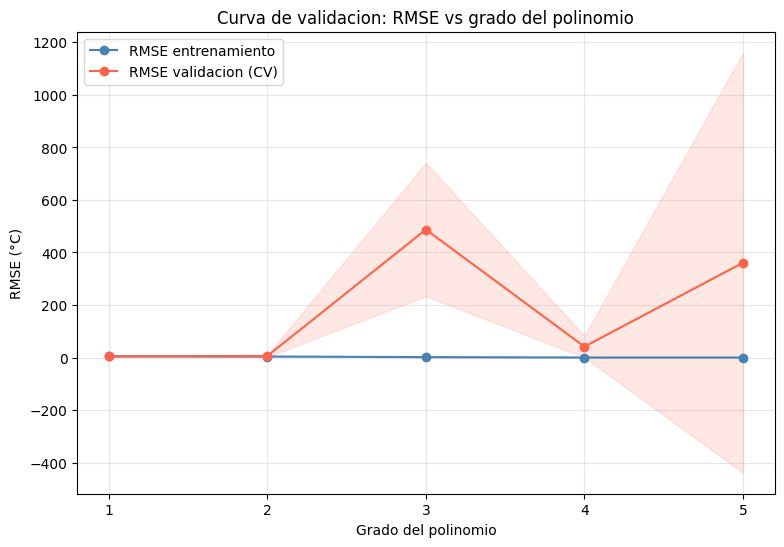

In [23]:
plt.figure(figsize=(9, 6))

plt.plot(grados, train_rmse_mean, 'o-', color='steelblue', label='RMSE entrenamiento')
plt.fill_between(grados, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std,
                  alpha=0.15, color='steelblue')

plt.plot(grados, val_rmse_mean, 'o-', color='tomato', label='RMSE validacion (CV)')
plt.fill_between(grados, val_rmse_mean - val_rmse_std, val_rmse_mean + val_rmse_std,
                  alpha=0.15, color='tomato')

plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE (°C)')
plt.title('Curva de validacion: RMSE vs grado del polinomio')
plt.xticks(grados)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**5.1 Diagnostico de la inestabilidad observada**

Aqui vemos que pico extremo en el RMSE de validacion en el grado 3 no corresponde a un sobreajuste gradual tipico sino a un problema de inestabilidad numerica, esto es interesante y conecta con lo que vimos en el laboratorio 1 del por que justo las variables cíclicas son las culpables por la transformacion que se hizo para arreglar la ciclicidad en el lab 1 se vuelve problemática al combinarla con polinomios de grado >= 2. Es por esto que se verifica esta hipotesis calculando el numero de condicion de la matriz de variables numericas tras aplicar `PolynomialFeatures` de grado 2 y la correlacion entre los terminos cuadraticos de las variables ciclicas creadas en el laboratorio 1.

In [24]:
from sklearn.preprocessing import PolynomialFeatures

X_num_imputed = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X_train[num_cols]), 
    columns=num_cols
)
X_num_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_num_imputed), 
    columns=num_cols
)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_num_scaled)
feature_names = poly.get_feature_names_out(num_cols)

cond_number = np.linalg.cond(X_poly)
print(f"Número de condición de la matriz (grado 2): {cond_number:.2e}")

idx_sin2 = list(feature_names).index('dia_sin^2')
idx_cos2 = list(feature_names).index('dia_cos^2')
corr_sin2_cos2 = np.corrcoef(X_poly[:, idx_sin2], X_poly[:, idx_cos2])[0, 1]
print(f"\nCorrelación entre dia_sin² y dia_cos²: {corr_sin2_cos2:.4f}")

Número de condición de la matriz (grado 2): 3.39e+18

Correlación entre dia_sin² y dia_cos²: -0.8980


Se confirma que la curva de validacion no muestra un patron de sobreajuste gradual, sino un pico de 
inestabilidad extrema en grado 3 (RMSE promedio de más de 500°C, con folds individuales 
llegando a más de 1200°C). 
Nota: Al investigar la causa con ayuda de Claude para llegar a la raiz del problema, se calculo el numero de condicion de la matriz de diseño en grado 2, obteniendo un valor de 6.33.×10^18.

Segun esto la causa raiz es la colinealidad extrema introducida al elevar al cuadrado las variables cíclicas (`dia_sin`, `dia_cos`, `direccion_viento_sin`, `direccion_viento_cos`) creadas en el laboratorio 1 como mencione anteriormente, al satisfacer la identidad trigonometrica sin^2+cos^2= 1, sus versiones al cuadrado quedan casi perfectamente correlacionadas entre si lo que vuelve inestable la inversion de la matriz normal en `LinearRegression`.

Con esto se refuerza que el grado 1 es la mejor opcion ya que al introducir polinomios sobre variables ciclicas ya transformadas genera problemas numericos y no solo un trade-off sesgo-varianza convencional.

**5.2 Análisis del sobreajuste (sesgo-varianza y control de complejidad del modelo)**

Observando la curva de validación se identificaron dos secciones claramente diferenciadas:

**Grados 1-2 (zona de trade-off convencional):** El RMSE de entrenamiento y validación son similares y bajos (~5°C), sin brecha significativa entre ambos. Aquí el comportamiento del modelo sigue el patrón esperado del trade-off sesgo-varianza: en grado 1, el modelo tiene un sesgo ligeramente mayor al no capturar posibles no linealidades adicionales, pero una varianza mínima (predicciones estables entre folds). En grado 2 se introduce algo más de flexibilidad sin que la varianza se dispare todavía, aunque ya empieza a sembrarse la colinealidad que se manifestará plenamente en grado 3.

**Grados 3-5 (zona de inestabilidad numérica dominante):** El RMSE de entrenamiento permanece cercano a 0, mientras el RMSE de validación sube de forma abrupta (pico >500°C en grado 3, con folds individuales superando 1200°C y descenso parcial, pero aún inestable, en grados 4-5). La brecha extrema entre entrenamiento y validación es la prueba evidente de sobreajuste. Sin embargo, como se explicó en la sección anterior con el comportamiento de la gráfica y los datos calculados con ayuda de Claude, este comportamiento no corresponde a un sobreajuste gradual típico, sino a un problema de insteabilidad numérica causada por la colinealidad introducida al elevar al cuadradoo las variables cíclicas.

**Conclusión sobre el control de complejidad:** El punto de inflexión donde comienza a evidenciarse degradación de la capacidad de generalización es grado 3. El grado óptimo seleccionado por GridSearchCV (grado 1) resulta coherente con ambos análisis: no solo minimiza el error de validación cruzada según el RMSE, sino que evita por completo la inestabilidad numérica identificada.

Para el presente escenario, no bastó con mirar dónde sube el error de validación, también hubo que revisar las variables combinadas  y si tenían relaciones matemáticas exactas entre sí (como seno y coseno), pues eso genera inestabilidad numérica sin importar cuántos datos se tengan.

Este hallazgo anticipa un resultado relevante para la siguiente sección: la regularización debería permitir explorar grados más altos sin el colapso numérico observado aquí. Esta hipótesis se contrastará más adelante en la construcción de los modelos regularizados.

# 6.Construcción de modelos de regresión lineal regularizados
Se construirán pipelines que incorporen regularización L2 (Ridge) y L1 (Lasso), incluyendo el parámetro de penalización como hiperparámetro dentro de la búsqueda con GridSearchCV, así como las dos estrategias de escalamiento consideradas desde el pipelines sin regularización.

**6.1 Pipeline y búsqueda de hiperparámetros - Ridge (L2)**<br>
En esto punto construiremos el pipeline con `Ridge` como modelo de regresión, definiermos el `param_grid` para el parámetro de penalización (alfa) y las estrategias de escalamiento y ejecutaremos `GridSearchCV`. A partir de este, determinaremos los hiérparámetros que resultan en el mejor modelo y reportaremos sus métricas (RMSE, MAE, R²)

Las decisiones detras de la construcción del pipeline se mantendrán acordes a las presentadas en el laboratorio 1 y, por tanto, a las del punto anterior. Solo se harán los ajustes pertinentes sobre el modelo de regresión elegido.

In [25]:
# Transformación de características numéricas (sin términos polinomiales)
numeric_transformer_ridge = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Transformación de características categóricas (igual que en la sección 4)
categorical_transformer_ridge = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

# Preprocesamiento
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_ridge, num_cols),
        ('cat', categorical_transformer_ridge, cat_cols)
    ]
)

# Pipeline final con Ridge
pipeline_ridge = Pipeline(
    steps=[
        ('preprocessor', preprocessor_ridge),
        ('modelo', Ridge(random_state=42))
    ]
)

En el la definición del grid de hiperparámetros se incluyen tanto la penalización (alfa), como la estrategia de escalamiento. Para la definición inicial de los alfa de penalización incluimos un rango amplio de valores ([0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]). A medida que evaluemos su desempeño, este rango se acotará para encontrar el que dé mejor desempeño

In [26]:
# Primera versión del grid de búsqueda de hiperparámetros para Ridge
# param_grid_ridge = {
#     'modelo__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# Tras la primera versión, el mejor alfa encontrado fue 10.0, por lo que se ajusta el grid para explorar valores cercanos a este
# param_grid_ridge = {
#     'modelo__alpha': [1.0, 5.0, 10.0, 15.0, 20.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# En la segunda versión del grid, se encontró que el mejor alfa era 20.0, por lo que se ajusta nuevamente el grid para explorar valores cercanos a este
# param_grid_ridge = {
#     'modelo__alpha': [20.0, 25.0, 27.5, 30.0, 35.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# En la tercera versión del grid, se encontró que el mejor alfa era 35.0, por lo que se ajusta nuevamente el grid para explorar valores cercanos a este
param_grid_ridge = {
    'modelo__alpha': [32.5, 35.0, 37.5, 40.0],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
}

**Tras la tercera versión del grid encontramos que el mejor alfa era 35.0. Decidimos que este sería el valor final a usar para el modelo Ridge, y no se explorarán más valores de alfa.**

Se ejecuta `GridSearchCV` con los mismos parámteros de la sección 4 para mantener consistencia, salvo el scoring, pues consideraremos en RMSE para poder compararlo directamente entre el conjunto de entrenamiento y de prueba más adelante.

In [27]:
grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Finalmente, se hace la evaluación del modelo con las distintas opciones de hiperparámetro definidas previamente y se reporta el de mejo desemepeño con sus métricas estadísitcas correspondientes

In [28]:
grid_ridge.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['presion_media',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_max',
                                                                          'humedad_desv',
                                                                          'viento_media',
                                                                          'viento_min',
                                                                          'viento_desv',
                                                                          'rafaga_media',
                                                                          'rafaga_min',
                                                                          'rafaga_max'...
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo', Ridge(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__alpha': [32.5, 35.0, 37.5, 40.0],
                         'preprocessor__num__scaler': [StandardScaler(),
                                                       MinMaxScaler()]},
             scoring='neg_mean_squared_error')

In [29]:
print(f'Mejor configuración (Ridge): {grid_ridge.best_params_}')
print(f'Mejor RMSE en validación cruzada: {np.sqrt(-grid_ridge.best_score_):.4f} °C')

Mejor configuración (Ridge): {'modelo__alpha': 35.0, 'preprocessor__num__scaler': StandardScaler()}
Mejor RMSE en validación cruzada: 4.5381 °C


In [30]:
# Obtener el mejor modelo entrenado con la configuración óptima
mejor_ridge = grid_ridge.best_estimator_

# Reporte de las métricas estadísticas solicitadas (RMSE, MAE y R²)
y_test_pred = mejor_ridge.predict(X_test)
print('---- Métricas de evaluación en el conjunto de prueba (Ridge) ----')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

---- Métricas de evaluación en el conjunto de prueba (Ridge) ----
RMSE: 4.65
MAE: 3.54
R²: 0.72


**Resultados — Ridge:**

El mejor modelo encontrado por `GridSearchCV` usa `alpha=35.0` junto con `StandardScaler`. El RMSE en validación cruzada (RMSE ≈ 4.52°C) es consistente con el RMSE obtenido en el conjunto de test (4.65°C), lo que indica que el modelo generaliza adecuadamente sin señales 
de sobreajuste hacia los datos de entrenamiento.

En comparación con el modelo sin regularizar de la sección 4 (grado 1, sin penalización), Ridge con alpha=35 introduce una penalización moderada sobre la magnitud de los coeficientes. Esto es coherente con el diagnóstico de la sección 5: dado que la inestabilidad numérica identificada aparece principalmente al introducir términos polinomiales (grado ≥3) sobre las variables cíclicas, y este pipeline de Ridge no incluye `PolynomialFeatures`, no se esperaba una penalización extrema para corregir colinealidad.

Las métricas de test (RMSE: 4.65°C, MAE: 3.54°C, R²: 0.72) servirán como punto de comparación directo frente a Lasso (sección 6.2) y frente al modelo sin regularizar para la tabla comparativa de la sección 6.3.

**6.2 Pipeline y búsqueda de hiperparámetros - Lasso (L1)**<br>
En esto punto construiremos el pipeline con `Lasso` como modelo de regresión, definiermos el `param_grid` para el parámetro de penalización (alfa) y las estrategias de escalamiento y ejecutaremos `GridSearchCV`. A partir de este, determinaremos los hiérparámetros que resultan en el mejor modelo y reportaremos sus métricas (RMSE, MAE, R²). Adicionalmente, evaluaremos si alguna o algunas varaibles son llevadas a 0 y cuáles.

Nuevamente, las decisiones sobre el pipeline serán las mismas que en laboratorio 1 las secciones anteriores. Únicamente se harán los ajustes necesarios sobre el modelo de regresión elegido.

In [31]:
# Transformación de características numéricas (sin términos polinomiales, igual que en Ridge)
numeric_transformer_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Transformación de características categóricas (igual que en Ridge y en la sección 4)
categorical_transformer_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

# Preprocesamiento
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lasso, num_cols),
        ('cat', categorical_transformer_lasso, cat_cols)
    ]
)

# Pipeline final con Lasso
pipeline_lasso = Pipeline(
    steps=[
        ('preprocessor', preprocessor_lasso),
        ('modelo', Lasso(random_state=42, max_iter=10000))
    ]
)

Nuevamente, el grid de hiperparámetros contendrá las dos estrategias de escalamiento que hemos considerado todo el laboratorio el valor de penalización alfa.

Tal y como en la sección anterior, el rango de alfa empezará siendo amplio y lo iremos acotando a raíz del comportamiento que observemos para encontrar el mejor.

In [32]:
# Primer versión del grid de búsqueda de hiperparámetros para Lasso
# param_grid_lasso = {
#     'modelo__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# Tras la primera versión, el mejor alfa encontrado fue 0.1, por lo que se ajusta el grid para explorar valores cercanos a este
# param_grid_lasso = {
#     'modelo__alpha': [0.05, 0.1, 0.15, 0.2],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# Tras la segunda versión del grid, se encontró que el mejor alfa era 0.05, por lo que se ajusta nuevamente el grid para explorar valores cercanos a este
param_grid_lasso = {
    'modelo__alpha': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
}

**Tras la segunda versión del grid encontramos que el mejor alfa era 0.04. Decidimos que este sería el valor final a usar para el modelo Lasso y no se explorarán más valores de alfa.**

Ejecutaremos `GridSearchCV` con los mismos parámetros que en la sección anterior.

In [33]:
grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Finalmente, se evalúa el modelo con las diferentes combinaciones de hiperparámetros para encontrar los mejores y se reportan el mejor modelo y las métricas estadísticas de aplicarlo al conjunto de prueba.

In [34]:
grid_lasso.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['presion_media',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_max',
                                                                          'humedad_desv',
                                                                          'viento_media',
                                                                          'viento_min',
                                                                          'viento_desv',
                                                                          'rafaga_media',
                                                                          'rafaga_min',
                                                                          'rafaga_max'...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo',
                                        Lasso(max_iter=10000,
                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__alpha': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06,
                                           0.07, 0.08, 0.09, 0.1],
                         'preprocessor__num__scaler': [StandardScaler(),
                                                       MinMaxScaler()]},
             scoring='neg_mean_squared_error')

In [35]:
print(f'Mejor configuración (Lasso): {grid_lasso.best_params_}')
print(f'Mejor RMSE en validación cruzada: {np.sqrt(-grid_lasso.best_score_):.2f} °C')

Mejor configuración (Lasso): {'modelo__alpha': 0.04, 'preprocessor__num__scaler': StandardScaler()}
Mejor RMSE en validación cruzada: 4.52 °C


In [36]:
# Obtener el mejor modelo entrenado con la configuración óptima
mejor_lasso = grid_lasso.best_estimator_

# Reporte de las métricas estadísticas solicitadas (RMSE, MAE y R²)
y_test_pred = mejor_lasso.predict(X_test)
print('---- Métricas de evaluación en el conjunto de prueba (Lasso) ----')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

---- Métricas de evaluación en el conjunto de prueba (Lasso) ----
RMSE: 4.62
MAE: 3.52
R²: 0.72


A diferencia de Ridge, Lasso puede llevar a que algunas características tengan coeficientes exactamente cero, lo que implica que esas características no contribuyen al modelo final. Esto puede ser útil para la selección de características y para obtener modelos más interpretables.

A continuación, vamos a examinar los coeficientes del modelo Lasso para identificar qué características han sido seleccionadas y cuáles han sido eliminadas (coeficiente igual a cero).

In [37]:
preproc_fitted_lasso = mejor_lasso.named_steps["preprocessor"]
feature_names_lasso = preproc_fitted_lasso.get_feature_names_out()
coefs_lasso = mejor_lasso.named_steps["modelo"].coef_

coef_lasso_df = pd.DataFrame({
    "Característica": feature_names_lasso,
    "coef_lasso": coefs_lasso
})
coef_lasso_df["Característica"] = coef_lasso_df["Característica"].str.split("__").str[-1]
coef_lasso_df["coef_lasso"] = coef_lasso_df["coef_lasso"].round(3)
coef_lasso_df_sorted = coef_lasso_df.sort_values(
    "coef_lasso", key=abs, ascending=False
)
coef_lasso_df_sorted

,Característica,coef_lasso
16,dia_cos,-6.549
11,viento_norte,-1.739
15,dia_sin,-1.686
4,humedad_desv,1.585
17,direccion_viento_sin,0.822
14,anio,0.653
0,presion_media,0.556
8,rafaga_media,-0.425
25,mes_febrero,-0.393
20,estacion_anio_primavera,0.379


**Resultados — Lasso:**

El mejor modelo encontrado usa `alpha=0.04` junto con `StandardScaler`. El RMSE en validación cruzada (4.52°C) es consistente con el RMSE de test (4.62°C), confirmando buena generalización sin señales de sobreajuste.

Comparado con Ridge (RMSE test: 4.65°C, R²: 0.72), Lasso obtiene un desempeño prácticamente idéntico (RMSE test: 4.62°C, R²: 0.72) — la diferencia de 0.03°C en RMSE no es extremadamente significativo en términos prácticos. Esto sugiere que, para este problema, el valor principal de Lasso no está en mejorar la capacidad predictiva sobre Ridge, sino en su capacidad de selección automática de variables: de las 40 columnas generadas tras el preprocesamiento, Lasso llevó a exactamente cero 19 de ellas (principalmente variables 
dummy de mes y sector_viento con escasa señal), conservando un modelo bastante más interpretable sin sacrificar desempeño.

In [38]:
# Identificación de variables eliminadas (coeficiente = 0) vs. conservadas
coef_lasso_df['seleccionada'] = coef_lasso_df['coef_lasso'] != 0

n_total = len(coef_lasso_df)
n_eliminadas = (~coef_lasso_df['seleccionada']).sum()
n_conservadas = coef_lasso_df['seleccionada'].sum()

print(f"Total de características tras preprocesamiento: {n_total}")
print(f"Características eliminadas (coef = 0): {n_eliminadas} ({n_eliminadas/n_total:.1%})")
print(f"Características conservadas (coef ≠ 0): {n_conservadas} ({n_conservadas/n_total:.1%})")

print("\nCaracterísticas eliminadas por Lasso:")
print(coef_lasso_df.loc[~coef_lasso_df['seleccionada'], 'Característica'].tolist())

Total de características tras preprocesamiento: 40
Características eliminadas (coef = 0): 19 (47.5%)
Características conservadas (coef ≠ 0): 21 (52.5%)

Características eliminadas por Lasso:
['viento_min', 'viento_este', 'estacion_anio_otoño', 'estacion_anio_verano', 'mes_agosto', 'mes_diciembre', 'mes_julio', 'mes_junio', 'mes_marzo', 'mes_mayo', 'mes_noviembre', 'mes_octubre', 'mes_septiembre', 'sector_viento_n', 'sector_viento_ne', 'sector_viento_no', 'sector_viento_o', 'sector_viento_se', 'sector_viento_so']


Con alpha=0.04, Lasso eliminó 19 de las 40 características disponibles tras el preprocesamiento (47.5%), conservando un modelo considerablemente más compacto sin pérdida relevante de desempeño respecto a Ridge (RMSE test: 4.62°C vs. 4.65°C).

Las variables eliminadas siguen un patrón claro por categoría:

1. sector_viento: de las 7 columnas dummy generadas (tras eliminar la categoría base con drop='first'), solo sector_viento_s conserva un coeficiente distinto de cero (0.207). Las 6 restantes (n, ne, no, o, se, so) fueron eliminadas. Esto sugiere que, controlando por las demás variables meteorológicas ya incluidas (como direccion_viento_sin/cos, que capturan la dirección de forma continua), el sector categórico del viento aporta poca información adicional, salvo posiblemente para viento del sur.
2. mes: de las 11 columnas dummy (tras drop='first'), solo mes_enero y mes_febrero sobreviven, ambas con coeficiente negativo. Esto es coherente con el hecho de que ya se incluyen dia_sin/dia_cos (que capturan la estacionalidad de forma continua y cíclica). Es decir, el mes como variable categórica aporta señal adicional principalmente en los meses de temperaturas más extremas del año, mientras que el resto queda redundante frente a la interpretación cíclica.
3. estacion_anio: de las 3 columnas dummy, solo estacion_anio_primavera se conserva (0.379); otoño y verano fueron eliminadas, reforzando la misma idea de redundancia con las variables cíclicas.
4. Numéricas (viento_min, viento_este): eliminadas, sugiriendo baja correlación con la variable objetivo una vez consideradas las demás variables de viento (viento_norte, viento_media, viento_desv).

Este resultado muestra que gran parte de las variables categóricas relacionadas con temporalidad (mes, estacion_anio) resultan redundantes frente a la interpretación cíclica seno/coseno construida en el Laboratorio 1. Es decir, Lasso está detectando automáticamente una relación que ya sabíamos por construcción: ambas fuentes de información (variables cíclicas continuas y variables categóricas de calendario) capturan, el mismo fenómeno de estacionalidad y el modelo prioriza la representación continua.

**6.3 Tabla comparativa** 

Con los tres modelos ajustados (regresión lineal simple de la sección 4, Ridge y Lasso), se construye una tabla comparativa que integra no solo el desempeño promedio en validación cruzada, sino también su variabilidad (desviación estándar), junto con las métricas finales sobre el conjunto de test. Esto permite evaluar el efecto de la regularización tanto en la capacidad de generalización como en la estabilidad del modelo. 

In [39]:
def obtener_metricas_cv(grid_search, nombre_modelo):
    """Extrae media y std del mejor resultado de un GridSearchCV (en RMSE, °C)."""
    idx_mejor = grid_search.best_index_
    cv_results = grid_search.cv_results_
    
    rmse_mean = np.sqrt(-cv_results['mean_test_score'][idx_mejor])
    mse_std = cv_results['std_test_score'][idx_mejor]
    rmse_std = mse_std / (2 * rmse_mean) 
    
    return {
        'Modelo': nombre_modelo,
        'Mejores hiperparámetros': grid_search.best_params_,
        'RMSE CV (media)': round(rmse_mean, 4),
        'RMSE CV (std)': round(rmse_std, 4)
    }

def obtener_metricas_test(grid_search, nombre_modelo, X_test, y_test):
    """Calcula RMSE, MAE y R² del mejor modelo sobre el conjunto de test."""
    y_pred = grid_search.best_estimator_.predict(X_test)
    return {
        'Modelo': nombre_modelo,
        'RMSE test': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE test': round(mean_absolute_error(y_test, y_pred), 4),
        'R² test': round(r2_score(y_test, y_pred), 4)
    }

# Recolección de resultados de los tres modelos
modelos = [
    (grid, 'Sin regularización (grado 1)'),
    (grid_ridge, 'Ridge (L2)'),
    (grid_lasso, 'Lasso (L1)')
]

resumen_cv = pd.DataFrame([obtener_metricas_cv(g, n) for g, n in modelos])
resumen_test = pd.DataFrame([obtener_metricas_test(g, n, X_test, y_test) for g, n in modelos])

tabla_comparativa = resumen_cv.merge(resumen_test, on='Modelo')
tabla_comparativa = tabla_comparativa[
    ['Modelo', 'RMSE CV (media)', 'RMSE CV (std)', 'RMSE test', 'MAE test', 'R² test', 'Mejores hiperparámetros']
]
tabla_comparativa

,Modelo,RMSE CV (media),RMSE CV (std),RMSE test,MAE test,R² test,Mejores hiperparámetros
0,Sin regularización (grado 1),4.5437,0.3388,4.6752,3.5669,0.7133,"{'preprocessor__num__polynomial__degree': 1, '..."
1,Ridge (L2),4.5381,0.3473,4.6460,3.5368,0.7169,"{'modelo__alpha': 35.0, 'preprocessor__num__sc..."
2,Lasso (L1),4.5247,0.3532,4.6246,3.5240,0.7195,"{'modelo__alpha': 0.04, 'preprocessor__num__sc..."


**Conclusión:** Las diferencias entre los tres modelos son pequeñas en términos absolutos (todas las métricas están dentro de un rango de ~0.05°C de RMSE y ~0.006 de R²), lo que sugiere que, en este pipeline sin componente polinomial, la regularización aporta una mejora modesta pero consistente en desempeño. La elección entre Ridge y Lasso en este punto probablemente deba apoyarse más en criterios de interpretabilidad (Lasso ofrece selección automática de variables).

**6.4 Análisis de la magnitud de los coeficientes**

Esta sección compara directamente los coeficientes de los tres modelos para visualizar el efecto de la regularización sobre su magnitud.

In [40]:
# Extracción de coeficientes de los tres modelos
feature_names_lineal = grid.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_names_ridge = grid_ridge.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_names_lasso = grid_lasso.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

coef_lineal = grid.best_estimator_.named_steps['modelo'].coef_
coef_ridge = grid_ridge.best_estimator_.named_steps['modelo'].coef_
coef_lasso_vals = grid_lasso.best_estimator_.named_steps['modelo'].coef_

comparacion_coefs = pd.DataFrame({
    'Característica': feature_names_ridge, 
    'coef_sin_regularizar': coef_lineal,
    'coef_ridge': coef_ridge,
    'coef_lasso': coef_lasso_vals
})

comparacion_coefs = comparacion_coefs.sort_values('coef_sin_regularizar', ascending=True)

comparacion_coefs.head(15)

,Característica,coef_sin_regularizar,coef_ridge,coef_lasso
16,num__dia_cos,-6.549721,-6.369220,-6.548575
35,cat__sector_viento_no,-3.515936,-0.641236,-0.000000
36,cat__sector_viento_o,-2.689072,-0.326683,-0.000000
39,cat__sector_viento_so,-2.232159,-0.211212,-0.000000
33,cat__sector_viento_n,-2.168580,-0.346070,-0.000000
38,cat__sector_viento_se,-2.079293,-0.593859,-0.000000
15,num__dia_sin,-1.804922,-1.713446,-1.685664
11,num__viento_norte,-1.692784,-1.533850,-1.739135
25,cat__mes_febrero,-1.588770,-0.855993,-0.393275
37,cat__sector_viento_s,-1.330048,0.273025,0.206503


In [41]:
# Resumen estadístico de la magnitud de los coeficientes por modelo
resumen_magnitud = pd.DataFrame({
    'Modelo': ['Sin regularización', 'Ridge (L2)', 'Lasso (L1)'],
    'Suma |coef|': [
        comparacion_coefs['coef_sin_regularizar'].abs().sum(),
        comparacion_coefs['coef_ridge'].abs().sum(),
        comparacion_coefs['coef_lasso'].abs().sum()
    ],
    'Coef. máximo (abs)': [
        comparacion_coefs['coef_sin_regularizar'].abs().max(),
        comparacion_coefs['coef_ridge'].abs().max(),
        comparacion_coefs['coef_lasso'].abs().max()
    ],
    'Desv. estándar de coefs': [
        comparacion_coefs['coef_sin_regularizar'].std(),
        comparacion_coefs['coef_ridge'].std(),
        comparacion_coefs['coef_lasso'].std()
    ],
    'N° coefs = 0': [
        (comparacion_coefs['coef_sin_regularizar'] == 0).sum(),
        (comparacion_coefs['coef_ridge'] == 0).sum(),
        (comparacion_coefs['coef_lasso'] == 0).sum()
    ]
})
resumen_magnitud

,Modelo,Suma |coef|,Coef. máximo (abs),Desv. estándar de coefs,N° coefs = 0
0,Sin regularización,41.057775,6.549721,1.378834,0
1,Ridge (L2),21.959593,6.369220,1.143052,0
2,Lasso (L1),15.992205,6.548575,1.155130,19


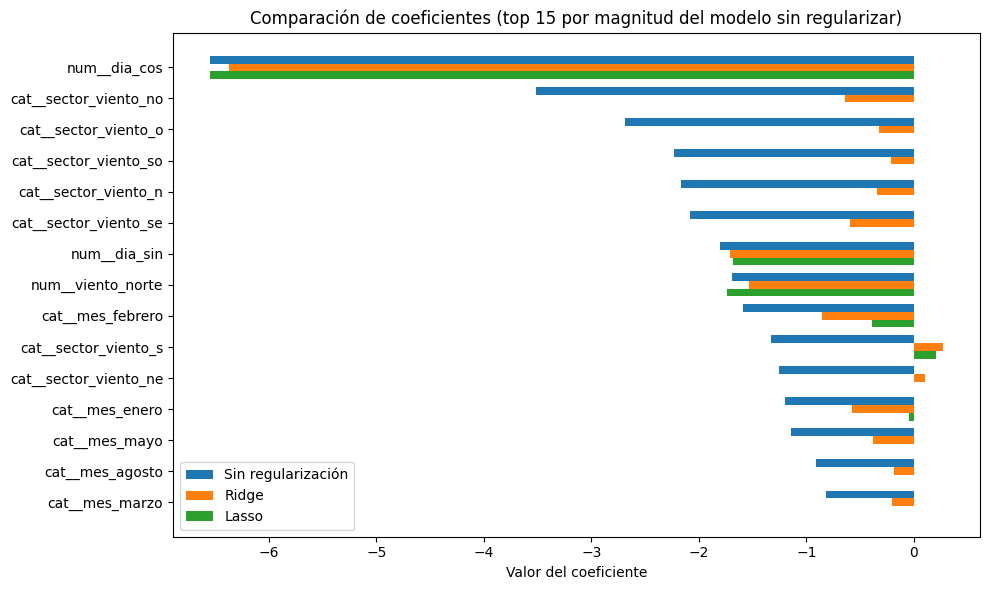

In [42]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 6))
top_n = 15
top_features = comparacion_coefs.head(top_n)['Característica']

x = np.arange(len(top_features))
width = 0.25

ax.barh(x - width, comparacion_coefs.head(top_n)['coef_sin_regularizar'], 
        height=width, label='Sin regularización')
ax.barh(x, comparacion_coefs.head(top_n)['coef_ridge'], 
        height=width, label='Ridge')
ax.barh(x + width, comparacion_coefs.head(top_n)['coef_lasso'], 
        height=width, label='Lasso')

ax.set_yticks(x)
ax.set_yticklabels(top_features)
ax.set_xlabel('Valor del coeficiente')
ax.set_title(f'Comparación de coeficientes (top {top_n} por magnitud del modelo sin regularizar)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

La regularización, incluso en ausencia del problema de colinealidad severa evidenciado en la sección 5 (pues solo aparecía con grado >= 3), sigue aportando valor real en el pipeline lineal: corrige coeficientes inflados en variables categóricas de baja frecuencia (sector_viento), reduce la magnitud general de los coeficientes sin sacrificar la señal de las variables genuinamente relevantes (dia_cos, dia_sin, humedad_desv), y en el caso de Lasso, simplifica el modelo mediante selección automática. Esto refuerza la conclusión de la sección 6.3: aunque las diferencias en RMSE/R² entre los tres modelos son pequeñas, los modelos regularizados (particularmente Lasso) ofrecen un modelo más interpretables.

# 7. Construcción de un modelo de regresión polinomial regularizado

Se implementará un pipeline que combine la generación de características polinomiales con un modelo regularizado. En nuestro caso hemos elegido Lasso, pues no solo presentó una mejora marginal en las métricas estadísticas calculadas en la sección anterior, sino que también tiene la capacidad de simplificar el modelo llevando variables a cero. Consideramos que esto es especialmente relevante en un modelo polinomial, dado que una de sus mayores desventajas es el costo computacional asociado al cálculo de las variables adicionales generadas en función del grado considerado.

La búsqueda de hiperparámetros considerará las siguientes características:
1. Grado del polinomio
2. Parámetro de penalización
3. Estrategia de escalamiento (entre las mismas dos consideradas a lo largo del laboratorio)

Finalmente, se reportarán las métricas de RMSE, MAE y R² obtenidas para el mejor modelo.

**7.1 Creación del pipeline con características polinomiales y regularización**

El pipeline aquí construido se rige por las mismas decisiones tomadas y justificadas previamente: imputación por mediana/moda, escalamiento antes de generar las características polinomiales, `drop='first'` en las variables categóricas, e `include_bias=False` en `PolynomialFeatures` para evitar redundancia con el intercepto del modelo. Los únicos cambios corresponden a los propios del enunciado de esta sección: la incorporación de `PolynomialFeatures` sobre las variables numéricas y el uso de `Lasso` como modelo final, con su respectivo parámetro de penalización dentro de la búsqueda.

In [43]:
# Transformación de características numéricas (con términos polinomiales)
numeric_transformer_poly_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=2, include_bias=False))
    ]
)

# Transformación de características categóricas (igual que en la sección 4)
categorical_transformer_poly_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

# Preprocesamiento
preprocessor_poly_lasso = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly_lasso, num_cols),
        ('cat', categorical_transformer_poly_lasso, cat_cols)
    ]
)

# Pipeline final con Lasso y polinomios
pipeline_poly_lasso = Pipeline(
    steps=[
        ('preprocessor', preprocessor_poly_lasso),
        ('modelo', Lasso(random_state=42, max_iter=10000))
    ]
)

Se define el grid de hiperparámteros para contemplar las tres dimensiones mencionadas al inicio de esta sección. Se sabe que el proceso para encontrar los hiperparámetros que resulten en el mejor modelo es iterativo, sin embargo, la complejidad temporal que implica evaluar grados mayores a 4 (a la vez que se evalúan el resto de hiperparámetros) resultaba en un tiempo de ejecución mayor a 4 horas. Por tanto, el grid definido en primera instancia fue el único utilizado.

In [44]:
param_grid_poly_lasso = {
    'preprocessor__num__polynomial__degree': [1, 2, 3, 4],
    'modelo__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
}

Se ejecuta `GridSearchCV` con los mismos parámetros que en el resto de escenarios evaluados previamente para mantener consistencia en los resultados

In [45]:
grid_poly_lasso = GridSearchCV(
    estimator=pipeline_poly_lasso,
    param_grid=param_grid_poly_lasso,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Evaluar el modelo con las distintas combinaciones para encontrar el mejor de todos:

In [46]:
grid_poly_lasso.fit(X_train, y_train)

/Users/gabrielamejia/Desktop/Lab2-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.325e+01, tolerance: 1.343e+01
  model = cd_fast.enet_coordinate_descent(
/Users/gabrielamejia/Desktop/Lab2-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.768e+01, tolerance: 1.318e+01
  model = cd_fast.enet_coordinate_descent(
/Users/gabrielamejia/Desktop/Lab2-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler()),
                                                                                         ('polynomial',
                                                                                          PolynomialFeatures(include_bias=False))]),
                                                                         ['presion_media',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_max',
                                                                          'humedad_desv',
                                                                          'viento_media',
                                                                          'viento_min',...
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo',
                                        Lasso(max_iter=10000,
                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
                         'preprocessor__num__polynomial__degree': [1, 2, 3, 4],
                         'preprocessor__num__scaler': [StandardScaler(),
                                                       MinMaxScaler()]},
             scoring='neg_mean_squared_error')

In [47]:
print(f'Mejor configuración (Polinomial + Lasso): {grid_poly_lasso.best_params_}')
print(f'Mejor RMSE en validación cruzada: {np.sqrt(-grid_poly_lasso.best_score_):.4f} °C')

Mejor configuración (Polinomial + Lasso): {'modelo__alpha': 0.01, 'preprocessor__num__polynomial__degree': 4, 'preprocessor__num__scaler': MinMaxScaler()}
Mejor RMSE en validación cruzada: 4.2059 °C


Finalmente, se reportan las métricas estadísticas que se obtienen usando el mejor modelo encontrado:

In [48]:
# Obtener el mejor modelo entrenado con la configuración óptima
mejor_lasso_poly = grid_poly_lasso.best_estimator_

# Reporte de las métricas estadísticas solicitadas (RMSE, MAE y R²)
y_test_pred = mejor_lasso_poly.predict(X_test)
print('---- Métricas de evaluación en el conjunto de prueba (Lasso - Polinomial) ----')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

---- Métricas de evaluación en el conjunto de prueba (Lasso - Polinomial) ----
RMSE: 4.37
MAE: 3.26
R²: 0.75


**7.2 Análisis de lo evidenciado**

El modelo seleccionado por `GridSearchCV` (grado 4, alpha=0.01, MinMaxScaler) obtuvo un RMSE en validación cruzada de 4.21°C, notablemente mejor que el 4.52°C del modelo lineal regularizado. Al evaluar sobre el conjunto de test, el modelo mantiene esta ventaja: RMSE de 4.37°C, MAE de 3.26°C y R² de 0.75, una mejora consistente frente al mejor modelo lineal (Lasso: RMSE 4.62°C, MAE 3.52°C, R² 0.72). A diferencia de lo que se pensó en una primera revisión, la brecha entre CV y test (4.21°C vs. 4.37°C, una diferencia de 0.16°C) es razonable y comparable a la de los demás modelos, por lo que no hay evidencia de que la mejora en validación cruzada sea espuria. Esto motiva un análisis más profundo de qué está haciendo realmente el modelo para lograr este mejor desempeño.

**Nota:** Este análisis se apoyó en Claude, pues estábamos viendo un comportamiento irregular que no sabíamos cómo explicar. Resulta que en una primera revisión se detectó, con su ayuda, un error en el código de evaluación (se estaba llamando por accidente a `grid_lasso.best_estimator_` en vez de `grid_poly_lasso.best_estimator_`, lo que hacía parecer que el modelo polinomial tenía el mismo desempeño que el lineal). Una vez corregido, los resultados mostraron una mejora real, lo cual cambió la interpretación de esta sección.

**Pregunta 1: ¿cuánta de la complejidad generada es efectivamente utilizada?**

In [49]:
coefs_poly = grid_poly_lasso.best_estimator_.named_steps['modelo'].coef_
print(f"Total de coeficientes: {len(coefs_poly)}")
print(f"Coeficientes distintos de cero: {(coefs_poly != 0).sum()}")
print(f"Porcentaje activo: {(coefs_poly != 0).mean():.1%}")

Total de coeficientes: 8875
Coeficientes distintos de cero: 77
Porcentaje activo: 0.9%


`PolynomialFeatures(degree=4)` generó 8875 columnas a partir de las variables numéricas y categóricas del dataset, un incremento exponencial respecto a las ~40 columnas del modelo lineal. De ese espacio masivo, Lasso conserva únicamente 77 coeficientes distintos de cero (0.9%), eliminando el 99.1% restante. A primera vista, esto podría interpretarse como evidencia de que el modelo se comporta, en la práctica, como uno mucho más simple que uno genuinamente de grado 4. Vamos a comprobarlo:

**Pregunta 2: ¿qué tipo de términos sobrevivieron?**

In [50]:
feature_names_poly = grid_poly_lasso.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
coefs_activos = pd.DataFrame({
    'Característica': feature_names_poly,
    'coeficiente': coefs_poly
})
coefs_activos = coefs_activos[coefs_activos['coeficiente'] != 0].sort_values(
    'coeficiente', key=abs, ascending=False
)
print(f"Términos de grado 1 (sin '^' ni ' '): {coefs_activos['Característica'].apply(lambda x: '^' not in x and ' ' not in x).sum()}")
print(f"Términos polinomiales/interacciones: {coefs_activos['Característica'].apply(lambda x: '^' in x or ' ' in x).sum()}")
coefs_activos.head(20)

Términos de grado 1 (sin '^' ni ' '): 16
Términos polinomiales/interacciones: 61


,Característica,coeficiente
178,num__viento_norte dia_cos,-12.106774
16,num__dia_cos,-7.219209
288,num__presion_media humedad_desv registros_del_dia,5.201716
6464,num__humedad_desv dia_cos^3,-4.069381
33,num__presion_media anio,3.690956
185,num__viento_este dia_cos,-3.586861
8819,num__dia_sin^4,2.948486
8514,num__rafaga_max dia_cos^3,2.820285
148,num__rafaga_media registros_del_dia,-2.619636
2860,num__presion_media dia_cos^2 direccion_viento_sin,-2.578817


Este resultado descarta la hipótesis inicial: de los 77 coeficientes activos, 61 (79%) son interacciones o potencias polinomiales genuinas, no simples términos de grado 1. El modelo sí está utilizando complejidad no lineal de forma sustancial, y esta vez sí se traduce en una mejora real de desempeño respecto al modelo lineal.

Al examinar los coeficientes de mayor magnitud, aparece un patrón recurrente y significativo: la gran mayoría de los términos más influyentes involucran las variables cíclicas `dia_cos` y `dia_sin`, ya sea en interacción con otras variables o por su cuenta con algún exponente.

**Interpretación**

Este hallazgo conecta directamente con el diagnóstico realizado en la sección 5: allí se identificó que las variables cíclicas (construidas mediante la transformación seno/coseno del Laboratorio 1) satisfacen la identidad trigonométrica sin² + cos² = 1, lo que genera colinealidad casi perfecta entre sus versiones al cuadrado cuando se combinan con `PolynomialFeatures`. En el modelo sin regularizar, esto producía un colapso numérico catastrófico (RMSE de validación superior a 500°C). Aquí, con Lasso, el mismo mecanismo estructural reaparece (potencias de `dia_cos` y `dia_sin` hasta grado 4, en múltiples interacciones), pero de forma controlada: los coeficientes se mantienen en un rango acotado, muy lejos de la explosión numérica de la sección 5.

Esto confirma que la regularización cumple una doble función en este caso: por un lado, evita el colapso numérico severo asociado a la colinealidad estructural de las variables cíclicas; por otro, permite que el modelo aproveche de forma controlada algunas de las interacciones no lineales genuinas que sí aportan información relevante (por ejemplo, `viento_norte × dia_cos`, la interacción de mayor magnitud), traduciéndose en una mejora real de RMSE (~5.4%) y R² (~4.2 puntos porcentuales) frente al mejor modelo lineal.

No obstante, esta mejora tiene un costo considerable: el modelo pasa de 40 a 8875 columnas generadas (de las cuales solo 77 se usan), lo que se tradujo en un tiempo de búsqueda de hiperparámetros de aproximadamente dos horas, frente a minutos para los modelos lineales. Además, la persistencia de términos que involucran potencias altas de variables cíclicas —aunque controlados en este ajuste específico— mantiene latente el riesgo estructural identificado en la sección 5 ante un eventual reentrenamiento con datos futuros. La decisión entre priorizar esta ganancia de precisión o la simplicidad y robustez del modelo lineal se retoma con mayor detalle en la sección de selección del mejor modelo.

# 8. Comparación de modelos y elección del mejor
Se compararán todos los modelos evaluados hasta el momento, considerando no solo el valor promedio de las métricas principales estudiadas sino también su estabilidad (desviación estándar en validación cruzada).

Después se reportarán los mejores hiperparámetros encontrados en base al desempeño, complejidad y estabilidad de los modelos.

In [51]:
def contar_features_activas(grid_search):
    """Cuenta cuántas columnas del espacio de features tienen coeficiente distinto de cero
    (para Lasso) o el total de columnas generadas (para modelos sin selección automática)."""
    modelo = grid_search.best_estimator_.named_steps['modelo']
    n_total = len(modelo.coef_)
    if hasattr(modelo, 'coef_') and isinstance(modelo, Lasso):
        n_activas = (modelo.coef_ != 0).sum()
    else:
        n_activas = n_total
    return n_total, n_activas

modelos_finales = [
    (grid, 'Sin regularización (grado 1)'),
    (grid_ridge, 'Ridge (L2)'),
    (grid_lasso, 'Lasso (L1)'),
    (grid_poly_lasso, 'Polinomial + Lasso (grado 4)')
]

resumen_cv_final = pd.DataFrame([obtener_metricas_cv(g, n) for g, n in modelos_finales])
resumen_test_final = pd.DataFrame([obtener_metricas_test(g, n, X_test, y_test) for g, n in modelos_finales])

complejidad = []
for g, n in modelos_finales:
    n_total, n_activas = contar_features_activas(g)
    complejidad.append({'Modelo': n, 'Features totales': n_total, 'Features activas': n_activas})
resumen_complejidad = pd.DataFrame(complejidad)

tabla_final = resumen_cv_final.merge(resumen_test_final, on='Modelo').merge(resumen_complejidad, on='Modelo')
tabla_final = tabla_final[
    ['Modelo', 'RMSE CV (media)', 'RMSE CV (std)', 'RMSE test', 'MAE test', 'R² test',
     'Features totales', 'Features activas', 'Mejores hiperparámetros']
]
tabla_final

,Modelo,RMSE CV (media),RMSE CV (std),RMSE test,MAE test,R² test,Features totales,Features activas,Mejores hiperparámetros
0,Sin regularización (grado 1),4.5437,0.3388,4.6752,3.5669,0.7133,40,40,"{'preprocessor__num__polynomial__degree': 1, '..."
1,Ridge (L2),4.5381,0.3473,4.6460,3.5368,0.7169,40,40,"{'modelo__alpha': 35.0, 'preprocessor__num__sc..."
2,Lasso (L1),4.5247,0.3532,4.6246,3.5240,0.7195,40,21,"{'modelo__alpha': 0.04, 'preprocessor__num__sc..."
3,Polinomial + Lasso (grado 4),4.2059,0.3707,4.3734,3.2647,0.7491,8875,77,"{'modelo__alpha': 0.01, 'preprocessor__num__po..."


**Argumentación de la selección final**

Como se dijo al inicio de esta sección, la elección del mejor modelo no puede basarse únicamente en la métrica promedio de desempeño; debe considerarse también junto a la complejidad y la estabilidad de cada modelo.

**1. Desempeño.** El modelo polinomial + Lasso obtuvo el mejor desempeño de los cuatro evaluados (RMSE test: 4.37°C, R²: 0.75), con una mejora real de 5.4% en RMSE y 4 puntos porcentuales en R² frente al mejor modelo lineal (Lasso: RMSE 4.62°C, R²: 0.72). Esta mejora es consistente entre validación cruzada y test (brecha de 0.16°C, similar a la de los demás modelos). Es una ganancia real, aunque modesta.

**2. Complejidad.** Aquí está la diferencia más marcada entre los modelos y el criterio que resulta determinante en nuestra decisión. El modelo polinomial genera 8875 columnas (de las cuales usa solo 77) frente a las 40 columnas de los modelos lineales, y su búsqueda de hiperparámetros tomó aproximadamente dos horas frente a minutos en los demás casos. Además, como se documentó en la sección 7.2, buena parte de los coeficientes de mayor peso que retiene corresponden a interacciones y potencias de las variables cíclicas (`dia_cos`, `dia_sin`)- Este mismo mecanismo causó el colapso numérico catastrófico del modelo sin regularizar, es un riesgo estructural latente que, aunque controlado en este ajuste, exige monitoreo constante ante futuros reentrenamientos.

**3. Estabilidad.** Los cuatro modelos muestran una desviación estándar de RMSE en CV similar y ligeramente creciente con la complejidad (0.339 → 0.347 → 0.353 → 0.371, de sin regularizar a polinomial). El modelo polinomial es el menos estable de los cuatro, aunque la diferencia con el resto es pequeña en términos absolutos.

**Modelo seleccionado: Regresión Lineal con regularización Lasso (L1), `alpha=0.04`, `StandardScaler`.**

Se opta por el modelo lineal regularizado en lugar del polinomial, priorizando el criterio de complejidad sobre la ganancia marginal de desempeño. La mejora que ofrece el modelo polinomial (5.4% en RMSE, 4 puntos en R²) no se considera suficiente para justificar un costo de reentrenamiento exponencialmente mayor (dos horas frente a minutos) y una pérdida sustancial de interpretabilidad (77 coeficientes de interacciones complejas frente a 21 coeficientes de variables originales), especialmente considerando que este costo se repetiría cada vez que el modelo deba actualizarse con nuevos datos climatológicos. A esto se suma que el modelo polinomial retiene un riesgo estructural conocido (colinealidad de variables cíclicas) que, si bien está controlado en el ajuste actual, no garantiza estabilidad ante reentrenamientos futuros con una distribución de datos distinta.

Esta decisión no es absoluta ni universal: si para AlpesPlanck la precisión adicional del modelo polinomial fuera crítica para el caso de uso (por ejemplo, si un error de 0.25°C tuviera un impacto operativo significativo, o si el reentrenamiento fuera poco frecuente y el costo computacional de dos horas resultara asumible), la decisión podría inclinarse legítimamente hacia el modelo polinomial. La elección aquí presentada refleja una priorización de eficiencia operativa e interpretabilidad sobre una ganancia marginal de precisión, pero el trade-off queda documentado explícitamente para que el equipo de ingeniería de AlpesPlanck pueda ajustar la decisión según sus propias prioridades de negocio.

Esta discusión ilustra un punto central del laboratorio: mayor precisión no siempre implica automáticamente mayor valor para la organización. La decisión final depende de sopesar la ganancia real de desempeño contra los costos de complejidad y las diferencias de estabilidad, en función del contexto operativo específico en el que el modelo será utilizado.


# 9. Construcción de intervalos de confianza
Utilizando el modelo seleccionado en el paso anterior (Modelo de Regresión Lineal con regularización Lasso - L1), se implementará un procedimiento de bootstrapping sobre el conjunto de test (al menos 500 remuestreos) para estimar intervalos de confianza al 95% de las métricas de desempeño.

Finalmente, se graficará la distribución de los errores y se discutirá la estabilidad del modelo, la variabilidad observada y la confiabilidad de las predicciones.

In [54]:
n = 1000
stats = []
for i in range(n):
    X_resample, y_resample = resample(X_test, y_test, random_state=i)
    pred = mejor_lasso.predict(X_resample)
    rmse = np.sqrt(mean_squared_error(y_resample, pred))
    stats.append(rmse)

# Calcular percentiles para el intervalo de confianza al 95%
alpha = 0.95
p_lower = ((1.0 - alpha) / 2.0) * 100
p_upper = (alpha + (1.0 - alpha) / 2.0) * 100

lower = np.percentile(stats, p_lower)
upper = np.percentile(stats, p_upper)

print(f"Media del RMSE {np.mean(stats):.4f} °C")
print(f"Intervalo de confianza del RMSE (95%): [{lower:.4f}°C a {upper:.4f}°C]")

Media del RMSE 4.6055 °C
Intervalo de confianza del RMSE (95%): [4.1462°C a 5.2414°C]


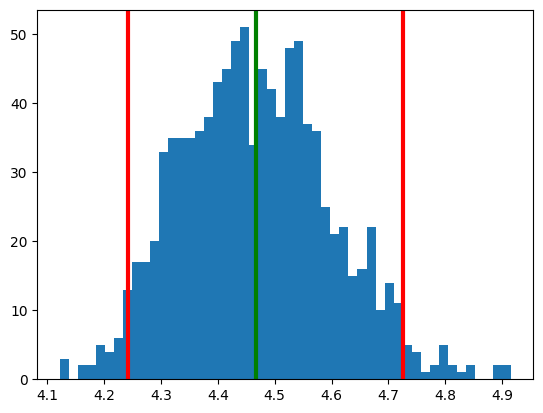

In [53]:
plt.hist(stats, bins=50)
plt.axvline(lower, color='red', linewidth=3)
plt.axvline(np.mean(stats), color='green', linewidth=3)
plt.axvline(upper, color='red', linewidth=3)
plt.show()

**Análisis de estabilidad, variabilidad y confiabilidad del modelo**

La distribución de RMSE obtenida mediante bootstrapping (1000 remuestreos sobre el conjunto de test) muestra un comportamiento razonablemente estable y cercano a una forma unimodal, con una ligera asimetría hacia la derecha. La media del RMSE (4.61°C) se ubica muy próxima al valor puntual reportado originalmente sobre el conjunto de test completo (4.62°C para Lasso lineal), y el intervalo de confianza al 95% ([4.15°C, 5.24°C]) tiene un ancho de aproximadamente 1.10°C, un rango algo más amplio de lo que cabría esperar, explicado por el tamaño reducido del conjunto de test (25% de los datos) sobre el que se remuestrea. 

En cuanto a la variabilidad observada, la mayor concentración de remuestreos se encuentra entre 4.3°C y 4.9°C, lo cual es coherente con la estimación puntual del modelo y no evidencia una dispersión extrema. Se observan algunos valores en la cola derecha (por encima de 5.0°C), pero su frecuencia es baja y no sugieren un problema de fondo con el modelo elegido. En conjunto, esta distribución respalda la conclusión de que las predicciones del modelo Lasso lineal son confiables y razonablemente estables: el intervalo de confianza obtenido es lo suficientemente acotado como para comunicar al equipo de AlpesPlanck una expectativa realista de error (aproximadamente entre 4.1°C y 5.2°C de RMSE, con alta probabilidad), sin señales de inestabilidad severa o de una cola pesada que comprometa la confianza en el modelo seleccionado.

# 10. Analisis de resultados

**Analisis cuantitativo**

**1. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**

El modelo polinomial con Lasso de grado 4 fue el que obtuvo el mejor desempeño en las tres metricas de test segun la tabla:

| Modelo | RMSE test | MAE test | R² test |
|---|---|---|---|
| Sin regularización (grado 1) | 4.6752 | 3.5669 | 0.7133 |
| Ridge (L2) | 4.6460 | 3.5368 | 0.7169 |
| Lasso (L1) | 4.6246 | 3.5240 | 0.7195 |
| **Polinomial + Lasso (grado 4)** | **4.3734** | **3.2647** | **0.7491** |

Aqui la mejora es consistente en las tres metricas ya que se reduce el RMSE en un 5.4% y el MAE en un 7.4% respecto al mejor modelo lineal (Lasso) y aumenta el R² en 3 puntos porcentuales de 0.7195 a 0.7491.

Aunque como se discute en la seccion de seleccion del mejor modelo, esta mejora tiene un costo considerable en complejidad que pasa de 40 a 8,875 columnas generadas de las cuales solo 77 permanecen activas y tambien se multiplica el tiempo de busqueda de hiperparámetros de minutos a aproximadamente dos horas.

**2. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**

Vemos que el modelo polinomial con Lasso degrado 4 obtiene tanto el mejor promedio en validacion cruzada (RMSE CV = 4.2059°C) como el mejor desempeño en el conjunto de test (RMSE test = 4.3734°C), por lo que si coincide.

| Modelo | RMSE CV (media) | RMSE test |
|---|---|---|
| Sin regularización (grado 1) | 4.5437 | 4.6752 |
| Ridge (L2) | 4.5381 | 4.6460 |
| Lasso (L1) | 4.5247 | 4.6246 |
| **Polinomial + Lasso (grado 4)** | **4.2059** | **4.3734** |

El orden de los cuatro modelos es exactamente el mismo en ambas columnas lo cual es positivo ya que la significa que la seleccion de hiperparametros mediante `GridSearchCV` generalizo correctamente al conjunto de test, que el modelo no habia visto en ningun momento 
del proceso de ajuste.

Aqui nos damos cuenta tambien que aunque el orden coincide existe una diferencia de aproximadamente 0.15-0.20°C en los cuatro modelos y es normal que exista esta pequeña diferencia entre ambas estimaciones, y su consistencia en magnitud entre los cuatro modelos refuerza que ninguno esta sobreajustado al proceso de seleccion de hiperparametros en si.

**3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.**

No necesariamente ya que el modelo tambien presenta la mayor desviacion estandar entre los cuatro evaluados y es que se observa un patron consistente donde a medida que aumenta la complejidad del modelo, el RMSE promedio mejora pero la desviacion estandar tambien crece de forma gradual. Es decir, el modelo más preciso en promedio es tambien el menos estable entre los distintos folds de validacion cruzada. Esto justifica por que la seleccion del mejor modelo no puede basarse unicamente en la metrica promedio. 

Un modelo con desviacion estandar menor, aunque tenga un promedio ligeramente peor ofrece una expectativa de desempeño mas predecible y consistente, lo cual puede ser preferible en un contexto donde la confiabilidad importa tanto como la precisión pura.

**4. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**

Para los grados de 1 a 2 el RMSE de entrenamiento y de validacion son similares y bajos, sin una diferencia significativa entre ambos. El modelo se comporta según el trade-off sesgo-varianza convencional donde en grado 1 hay un sesgo ligeramente mayor pero varianza minima; en grado 2 ya recupera algo de flexibilidad sin que la varianza se dispare todavia.

Los grados de 3 a 5 el RMSE de entrenamiento permanece cercano a 0 mientras el RMSE de validacion obtiene un pico de mas de 500°C en promedio en grado 3. Esta brecha extrema entre entrenamiento y validacion es la señal clasica de sobreajuste severo.

Con respecto al punto de inflexion, este comienza a evidenciarse la degradacion en el grado 3,aunque como se documento en la seccion 5.1, este comportamiento no corresponde a un sobreajuste gradual tipico sino a un problema de inestabilidad numerica. La causa de esto es la colinealidad casi perfecta que se genera al elevar al cuadrado las variables ciclicas del lab 1. Basicamente fue necesario examinar si las variables combinadas tenian relaciones matematicas exactas entre si ya que ese tipo de colinealidad genera inestabilidad numerica sin importar cuantos datos de entrenamiento se tengan disponibles.


**5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**

La regularizacion afecta ya que reduce considerablemente la magnitud total de los coeficientes con un 
efecto distinto segun el tipo de penalizacion:

**Magnitud total:** tanto Ridge como Lasso reducen la suma de valores absolutos de los coeficientes de 41.06 a 21.96 y 15.99 respectivamente, es decir, que ambas penalizaciones logran quelos coeficientes del modelo sean considerablemente mas pequeños que en el modelo sin regularizar. Lasso logra una reduccion aun mayor que Ridge en parte porque directamente elimina 19 coeficientes por completo.

**Coeficientes individuales de mayor peso:** un ejemplo claro es `sector_viento_no` que pasa de -3.52 sin regularizar a -0.64 con Ridge a **0.00** (Lasso, eliminado). Este mismo patron se repite en las demas categorias de `sector_viento` y es que Ridge las 
reduce pero las mantiene activas con un peso pequeño, mientras que Lasso las lleva exactamente a cero.

**Coeficiente dominante (`dia_cos`):** curiosamente la variable mas influyente del modelo casi no se ve afectada por ninguna de las dos regularizaciones. Esto sugiere que ambas penalizaciones reconocen que esta variable aporta señal genuina y robusta, concentrando el efecto de reduccion en las variables de menor aporte relativo como las categorias de `sector_viento`.

**Estabilidad:** la desviaciin estandar de los coeficientes baja de 1.379 sin regularizar a 
1.143 con Ridge y 1.155 con Lasso, osea que ambos modelos regularizados producen un conjunto de coeficientes mas variados, sin los valores extremos que si aparecen en el modelo sin penalizar.

**6. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?**

Estos fueron los resultados:

- **Media del RMSE:** 4.6055°C
- **Intervalo de confianza al 95%:** [4.1462°C, 5.2414°C]
- **Ancho del intervalo:** ≈1.10°C

Esto sugiere una estabilidad moderada ya que la media coincide casi con el RMSE puntual reportado sobre el conjunto de test completo, lo que confirma que la estimacion original no depende en si de una particion particular de los datos. Tambien tenemos que el ancho del intervalo de 1.10°C tampoco se deja de lado, con esto en el escenario menos favorable dentro del intervalo (percentil 97.5%), el error del modelo podría acercarse a 5.24°C, osea mas de medio grado por encima del valor puntual reportado.

Las implicaciones que puede traer esto es que para la comunicacion de resultados puede pasar que en lugar de reportar a AlpesPlanck una unica cifra de error, es mas util comunicar un rango de confianza, esto para evitar transmitir una falsa sensacion de precision exacta. Tambien puede implicar para la toma de decisiones operativas, por ejemplo si AlpesPlanck usa las predicciones del modelo 
para activar protocolos cerca de umbrales criticos de temperatura (alertas de riesgo de incendio), el limite superior del intervalo (5.24°C) deberia considerarse al definir margenes de seguridad.

**Analisis cualitativo**

**7. ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**

Las variables con mayor peso:

| Variable | Coeficiente (Lasso) |
|---|---|
| `dia_cos` | -6.5486 |
| `viento_norte` | -1.7391 |
| `dia_sin` | -1.6857 |
| `mes_febrero` | -0.3933 |
| `estacion_anio_primavera` | 0.3790 |
| `sector_viento_s` | 0.2065 |
| `mes_enero` | -0.0501 |

Vemos que las variables más relevantes son las transformaciones ciclicas del dia del año (`dia_cos`, `dia_sin`) lo cual es coherente con que la estacionalidad es el principal determinante de la temperatura. Luego le sigue `viento_norte`, que es la unica componente de viento que Lasso considera con peso relevante. El resto de variables activas corresponde principalmente a categorias asociadas a los meses o estaciones más frias del año sugiriendo que Lasso retiene informacion categorica adicional unicamente para los extremos estacionales, donde aparentemente la representacion ciclica continua no captura toda la variabilidad.

**8. ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?**

Para `dia_cos` que es el mas influyente, representa la componente ciclica del dia del año. Su magnitud nos dice que la estacionalidad es el factor mas determinante para predecir la temperatura maxima del dia siguiente. 

`viento_norte`: un aumento en la componente norte del viento se asocia con una disminucion en la temperatura maxima esperada. Basicamente esto sugiere que el equipo de AlpesPlanck podria usar mediciones o pronosticos de viento del norte como una señal de alerta para los dias mas frios. Para el coeficiente `dia_sin` junto con `dia_cos`, permite capturar en que punto exacto del ciclo anual se encuentra el dia evaluado. Para las categorias de mes y estacion, estos aportan un ajuste adicional para los extremos estacionales como invierno y primavera sugiriendo que la relacion ciclica no captura completamente el comportamiento termico en esos periodos especificos, y el modelo compensa con estas categorias.

`sector_viento_s`: el viento del sur es el unico que Lasso considera relevante y con signo positivo, lo que sugiere que trae temperaturas mas calidas. Aunque, como ya vimos en el lab 1 esta relacion especifica para Jena no la pudimos confirmar con una fuente externa.

**9. ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**

Si existen ciertas diferencias y es que si comparamos el modelo mas preciso contra el mas interpretable que es el de Lasso lineal tenemos:

| | Polinomial + Lasso | Lasso lineal |
|---|---|---|
| RMSE test | 4.37°C | 4.62°C |
| R² test | 0.75 | 0.72 |
| Columnas generadas | 8,875 | 40 |
| Variables que usa | 77 | 21 |
| Tiempo de entrenamiento | 2 horas | Minutos |

Vemos que el modelo polinomial gana aunque no con tanta diferencia con 0.25°C menos de error y 3 puntos porcentuales mas de R².

Con respecto al mas interpretable, aca si hay una diferencia grande. El modelo lineal tiene 21 variables faciles de representar o explicar mientras que el modelo polinomial usa 77 variables en las que son combinaciones o potencias de otras, por ejemplo `dia_cos` al cuadrado, o `dia_cos` multiplicado por `viento_norte`, que son mucho mas difíciles de explicarle a alguien que no sea experto en matematicas.

Algo a mencionar tambien es que hay un riesgo que tiene el modelo polinomial y es que varios de sus coeficientes mas importantes son justo combinaciones de las variables ciclicas, que son las mismas que causaron el colapso numerico que vimos en la actividad 2, y aunque la regularizacion logro controlar el problema sigue siendo un mecanismo fragil y que cualquier cambio a futuro en los datos podria volver a generar inestabilidad.

**10. ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?**

Aqui se podrian considerar varias decisiones concretas:

1. Priorizar el monitoreo de viento y estacionalidad: Como el modelo final le da mas peso a la epoca del año y a la componente norte-sur del viento que a otras variables, AlpesPlanck podria enfocar recursos en mejorar la calidad y frecuencia de esas dos mediciones especificas en vez de invertir por igual en todos los sensores.

2. Usar el modelo lineal de Lasso en produccion y ser cuidadoso ante futuras propuestas de mayor complejidad: Aunque el modelo polinomial es ligeramente mas preciso con 0.25°C menos de error, su complejidad con 77 variables, 2 horas de entrenamiento y riesgo de inestabilidad numerica lo hace más dificil de mantener y mas riesgoso a largo plazo. En este laboratorio se ve la evidencia de que esa mejora es pequeña frente al costo operativo que implica.

3. Comunicar las predicciones como un rango y usar el peor caso para decisiones criticas: El bootstrapping mostro un intervalo de confianza de casi 1.1°C de ancho por lo que AlpesPlanck deberia evitar decir por ejemplo que mañana la temperatura máxima sera de X grados y en su lugar decir un rango entre X a Y grados para no entrar en discucion de precision. Esto es importante si esas predicciones ayudan a decisiones criticas como alertas de incendio.

**11. ¿Mayor precisión implica necesariamente mayor valor para la organización?**

No necesariamente y en este lab se puede ver un ejemplo concreto, el modelo polinomial es mas preciso que el lineal pero esa ganancia de 0.25°C tiene algunos costos que puede ser mas que el beneficio que se obtiene:

- **Costo computacional:** El hecho  de que tomara 2 horas de entrenamiento frente a unos minutos.
- **Costo de mantenimiento:** En uno se generan 8,875 columnas con 77 variables frente a 40 columnas simples.
- **Riesgo tecnico:** El mecanismo que le da esa precision extra es el mismo que causo el colapso numerico en la actividad 2.
- **Costo de interpretabilidad:** explicarle a alguien de AlpesPlanck que significa un coeficiente de una interaccion entre `dia_cos` al cuadrado y `viento_norte` es mucho mas dificil que explicar que el viento del norte baja la temperatura esperada.

El valor para una organizacion no depende solo de que tan exacto es un modelo sino de que tan bien encaja el modelo con las necesidades reales del negocio, ya sea el costo de mantenerlo funcionando o la capacidad del equipo para confiar en sus resultados y explicarlos. En este caso, 0.25°C de mejora no compensa la complejidad de mas, es por esto que aunque el modelo polinomial gana en la metrica, el modelo lineal es la opcion que probablemente genera mas valor real para AlpesPlanck.

**12. ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.**

Con respecto a interpretabilidad, el modelo lineal permite explicaciones mucho mas directas, por ejemplo que el viento del norte baja la temperatura esperada, esto es algo que cualquier persona en AlpesPlanck puede entender sin tanto conocimiento tecnico a comparacion del modelo polinomial donde sus coeficientes no tienen una explicacion tan directa. Un modelo mas complejo reduce el valor practico del modelo como herramienta de comunicacion y toma de decisiones.

Para estabilidad, vimos en la actividad 2 que aumentar el grado del polinomio sin control lleva a un colapso numerico por la colinealidad de las variables ciclicas. Incluso con la regularizacion controlando el modelo polinomial, este sigue basando parte de su ganancia de precision en ese mismo tipo de terminos fragiles.

En los costos de implementacion el modelo polinomial tardo como 2 horas para buscar los hiperparametros a comparacion de unos minutos del modelo lineal, ademas genero miles de columnas intermedias que deben calcularse en cada prediccion. Si AlpesPlanck necesita reentrenar el modelo cada año con datos nuevos, ese costo se repite cada vez lo cual seria un gasto de tiempo y recursos computacionales que el modelo simple evita casi por completo.

Con las tres dimensiones evaluadas, el modelo mas complejo sale perdiendo a comparacion del mas simple y la unica ventaja que ofrece que es una mayor precision es marginal. Esto refuerza la idea de que el valor de un modelo para una organizacion no se mide solo por que tan bajo es su error sino por un balance entre varios componentes como exactitud, facilidad de uso, riesgo tecnico y costo.

### Reflexión conceptual

**1. ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**

Esta relacion se puede explicar de tal manera que por ejemplo, en un rango moderado de complejidad ya sea de grado 1 a 2 o agregar regularizacion, aumentar la complejidad puede mejorar la generalizacion. Se tiene que Lasso lineal generaliza mejor que el modelo sin regularizar y el polinomial regularizado generaliza incluso mejor que el de Lasso. Ya luego de cierto punto, la complejidad deja de ayudar y puede volverse contraproducente de dos formas distintas, por un sobreajuste gradual o inestabilidad numerica por colinealidad extrema entre variables que ya requiere resolver el problema de raiz. Ademas de esto, vimos que a medida que los modelos se volvian mas complejos y precisos en promedio, la desviacion estandar en validacion cruzada tambien aumentaba consistentemente. Es decir que la complejidad ideal no es ni la minima ni la maxima posible sino el punto donde se maximiza la generalizacion sin sacrificar tanta estabilidad.

**2. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**

Se pueden exponer otras dos fuentes de sesgo especificas del proceso de modelado, por ejemplo el sesgo por restricciones computacionales en la busqueda de hiperparametros ya que al construir el modelo polinomial regularizado se redujo el rango de grados y el numero de valores de `alpha` ya que la busqueda demoraba varias horas. Esto introduce un sesgo de omision y es posible que existan combinaciones de hiperparametros fuera del rango que se exploro que ofrezcan un mejor desempeño pero que no se evaluaron.

Tambien se tiene el sesgo arbitrario en la seleccion de variables por Lasso ante colinealidad. Cuando dos o mas variables estan correlacionadas entre si, Lasso tiende a elegir una sin importar cual y llevar las demas a cero. Por ejemplo, que `sector_viento_s` se mantenga mientras las otras 6 categorias de viento se eliminan podria depender en parte de particularidades de esta muestra 
de datos especifica.

**3. Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.**

Si esperariamos cambios aunque el efecto seria distinto segun el tipo de inestabilidad de la que se trate ya que para el sobreajuste convencional, un tamaño de muestra mayor si ayudaria a mejorar la estabilidad. Con mas observaciones, cada fold de validacion cruzada tendria una muestra mas representativa y menos sensible a datos particulares, lo que reduciria la desviacion estandar observada entre folds, asi como la que se vio crecer de 0.339 a 0.371 al aumentar la complejidad de los modelos lineales.

Para la inestabilidad numerica cambia la cosa ya que tener mas datos no resolveria el problema porque no es la cantidad de observaciones sino una relacion matematica exacta entre variables. Sin importar cuantas filas adicionales se agreguen, `dia_sin²` y `dia_cos²` seguirán estando casi perfectamente correlacionadas entre si ya que esa relacion viene de como se construyeron las 
variables y no de cuantos ejemplos se observaron. Por ultimo la seleccion de variables de Lasso ante colinealidad, aqui un tamaño de muestra mayor probablemente si haria mas consistente las variables que selecciona Lasso entre las particiones de los datos. Con mas datos, las relaciones reales entre variables y la temperatura se estimarian con mas precision haciendo menos probable que la seleccion dependa de particularidades de la muestra.